# import module

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import BartTokenizerFast, BartForSequenceClassification
import torch
from torch.utils.data import Dataset
import numpy as np
from sklearn.metrics import recall_score, f1_score, roc_auc_score
from scipy.special import softmax
from transformers import Trainer, TrainingArguments

# 데이터셋 불러오기

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
CSV_PATH = '/content/drive/MyDrive/1. Project/online grooming detection/train_grooming.csv'
df = pd.read_csv(CSV_PATH, encoding='cp949')
df

,text,label
0,<SPEAKER_A>안녕! <SPEAKER_B>안녕! <SPEAKER_A>잘 지냈어...,1
1,<SPEAKER_A>이번 주말에 어때? <SPEAKER_A>달콤한 사람아 <SPEA...,1
2,<SPEAKER_A>안녕! <SPEAKER_A>안녕! <SPEAKER_A>좀 늦었는...,1
3,<SPEAKER_A>안녕! <SPEAKER_B>안녕! <SPEAKER_B>어디 갔었...,1
4,"<SPEAKER_A>안녕, 섹시! <SPEAKER_A>잘 지냈어? <SPEAKER_...",1
...,...,...
1833,"<SPEAKER_A>헤이,<SPEAKER_B>헤이야!<SPEAKER_A>너는 어때?...",0
1834,<SPEAKER_A>안녕<SPEAKER_B>안녕<SPEAKER_B>??<SPEAKE...,0
1835,<SPEAKER_A>안녕!<SPEAKER_B>안녕<SPEAKER_A>무슨 일이야?<...,0
1836,<SPEAKER_A>인터페이스에 HasProperty가 NamedGetter가 찾을...,0


In [4]:
from transformers import BartTokenizerFast, BartForSequenceClassification

# 1. tokenizer 먼저 불러오기
tokenizer = BartTokenizerFast.from_pretrained("gogamza/kobart-base-v2")

# 2. special tokens 추가
special_tokens_dict = {'additional_special_tokens': ['<SPEAKER_A>', '<SPEAKER_B>']}
num_added_tokens = tokenizer.add_special_tokens(special_tokens_dict)

print(f"✅ 추가된 토큰 수: {num_added_tokens}")  # 2가 나와야 정상

# 3. 모델 불러오기
model = BartForSequenceClassification.from_pretrained("gogamza/kobart-base-v2", num_labels=2)

# 4. 모델에 토큰 수 반영
model.resize_token_embeddings(len(tokenizer))

# 5. 확인
print("Special tokens:", tokenizer.special_tokens_map)
print("Token ID for <SPEAKER_A>:", tokenizer.convert_tokens_to_ids("<SPEAKER_A>"))
print("Token ID for <SPEAKER_B>:", tokenizer.convert_tokens_to_ids("<SPEAKER_B>"))
print("Token ID for </s> (eos):", tokenizer.convert_tokens_to_ids("</s>"))


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/4.00 [00:00<?, ?B/s]

...

✅ 추가된 토큰 수: 2


You passed along `num_labels=3` with an incompatible id to label map: {'0': 'NEGATIVE', '1': 'POSITIVE'}. The number of labels will be overwritten to 2.


model.safetensors:   0%|          | 0.00/495M [00:00<?, ?B/s]

Some weights of BartForSequenceClassification were not initialized from the model checkpoint at gogamza/kobart-base-v2 and are newly initialized: ['classification_head.dense.bias', 'classification_head.dense.weight', 'classification_head.out_proj.bias', 'classification_head.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Special tokens: {'bos_token': '</s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>', 'additional_special_tokens': ['<SPEAKER_A>', '<SPEAKER_B>']}
Token ID for <SPEAKER_A>: 30000
Token ID for <SPEAKER_B>: 30001
Token ID for </s> (eos): 1


#Custom Dataset

In [5]:
class GroomingDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=512):
        self.texts = df['text'].tolist()
        self.labels = df['label'].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

        # 스페셜 토큰 ID 저장
        self.speaker_tokens = [
            self.tokenizer.convert_tokens_to_ids('<SPEAKER_A>'),
            self.tokenizer.convert_tokens_to_ids('<SPEAKER_B>')
        ]

    def __len__(self):
        return len(self.texts)

    def find_valid_start(self, input_ids):
        # 뒤에서 max_len만큼 자르고, 해당 범위 내에서 가장 마지막 <SPEAKER_*> 토큰을 찾음
        start_idx = max(0, len(input_ids) - self.max_len)
        candidate = input_ids[start_idx:]

        for i in range(len(candidate)):
            if candidate[i] in self.speaker_tokens:
                return start_idx + i

        # 못 찾으면 그냥 max_len만큼 자른다
        return len(input_ids) - self.max_len

    def __getitem__(self, idx):
        text = self.texts[idx]
        encoded = self.tokenizer(
            text,
            add_special_tokens=False,
            return_attention_mask=False
        )
        input_ids = encoded["input_ids"]

        # valid_start를 찾아서 슬라이싱
        if len(input_ids) > self.max_len:
            valid_start = self.find_valid_start(input_ids)
            input_ids = input_ids[valid_start:]

        # special tokens 추가
        input_ids = self.tokenizer.build_inputs_with_special_tokens(input_ids)

        # attention mask 및 padding
        attention_mask = [1] * len(input_ids)
        padding_len = self.max_len + 2 - len(input_ids)

        input_ids += [self.tokenizer.pad_token_id] * padding_len
        attention_mask += [0] * padding_len

        return {
            'input_ids': torch.tensor(input_ids),
            'attention_mask': torch.tensor(attention_mask),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }




# 평가 지표

In [6]:
from sklearn.metrics import f1_score, recall_score, roc_auc_score, precision_score
import numpy as np
import torch # torch import 추가

def compute_metrics(eval_pred):
    logits_tuple, labels = eval_pred

    # ✅ logits가 (logits, ...) 구조일 경우 대응
    logits = logits_tuple[0] if isinstance(logits_tuple, (tuple, list)) else logits_tuple

    # ✅ softmax 적용
    softmax_probs = np.exp(logits) / np.sum(np.exp(logits), axis=1, keepdims=True)
    preds = np.argmax(softmax_probs, axis=1)

    # ✅ 안전성 고려: label이 단일 클래스일 경우 예외 처리
    try:
        auc = roc_auc_score(labels, softmax_probs[:, 1])
    except:
        auc = float('nan')

    return {
        "f1": f1_score(labels, preds, average='binary', zero_division=0),
        "recall": recall_score(labels, preds, average='binary', zero_division=0),
        "precision": precision_score(labels, preds, average='binary', zero_division=0),
        "auc_roc": auc
    }

# train val split

In [7]:
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=42)
train_dataset = GroomingDataset(train_df, tokenizer)
val_dataset = GroomingDataset(val_df, tokenizer)

# trainer 및 학습 코드

In [8]:
# 허깅페이스 trainer
# training_args = TrainingArguments(
#     output_dir="./kobart-grooming-checkpoints",
#     eval_strategy="steps",
#     eval_steps=10,
#     logging_steps=10,
#     save_steps=500,
#     per_device_train_batch_size=8,
#     per_device_eval_batch_size=8,
#     num_train_epochs=1,
#     learning_rate=5e-5,
#     weight_decay=0.01,
#     save_total_limit=1,
#     logging_dir="./logs"
# )

# trainer = Trainer(
#     model=model,
#     args=training_args,
#     train_dataset=train_dataset,
#     eval_dataset=val_dataset,
#     compute_metrics=compute_metrics
# )

In [10]:
#pytorch train_model
from torch.utils.data import DataLoader
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import torch
import numpy as np

def train_model(model, train_dataset, val_dataset, tokenizer, num_epochs=8, batch_size=8, learning_rate=5e-5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size)

    optimizer = AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)

    total_steps = len(train_loader) * num_epochs

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(total_steps * 0.1),
        num_training_steps=total_steps
    )

    best_val_accuracy = 0
    early_stop_counter = 0
    patience = 3  # You can adjust this value


    # 시각화를 위한 기록 리스트
    train_losses, val_losses, val_accuracies = [], [], []

    for epoch in range(num_epochs):
        print(f"\n📚 Epoch {epoch+1}/{num_epochs}")
        model.train()
        train_loss = 0

        for batch in tqdm(train_loader, desc="Training"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            train_loss += loss.item()
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        print(f"🔧 Avg Train Loss: {avg_train_loss:.4f}")

        # ===== Validation =====
        model.eval()
        all_preds = []
        all_labels = []
        val_loss = 0

        with torch.no_grad():
            for batch in tqdm(val_loader, desc="Validation"):
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)

                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels
                )

                loss = outputs.loss
                val_loss += loss.item()

                logits = outputs.logits
                preds = torch.argmax(logits, dim=1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        val_acc = accuracy_score(all_labels, all_preds)
        val_accuracies.append(val_acc)
        print(f"✅ Val Loss: {avg_val_loss:.4f} | Val Accuracy: {val_acc:.4f}")

        if val_acc > best_val_accuracy:
            best_val_accuracy = val_acc
            torch.save(model.state_dict(), "best_model.pth")
            print("📦 모델 저장됨!")
        else:
            early_stop_counter += 1
            print(f"⏹️ Early Stop Counter: {early_stop_counter}/{patience}")
            if early_stop_counter >= patience:
                print("🛑 Early stopping triggered.")
                break


    # 📊 시각화
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss per Epoch")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(val_accuracies, label="Val Accuracy", color="green")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Validation Accuracy per Epoch")
    plt.legend()

    plt.tight_layout()
    plt.show()

    # 🧩 Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Normal", "Grooming"], yticklabels=["Normal", "Grooming"])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()


📚 Epoch 1/8


Training: 100%|██████████| 184/184 [02:45<00:00,  1.12it/s]


🔧 Avg Train Loss: 0.1342


Validation: 100%|██████████| 46/46 [00:13<00:00,  3.33it/s]


✅ Val Loss: 0.0000 | Val Accuracy: 1.0000
📦 모델 저장됨!

📚 Epoch 2/8


...

✅ Val Loss: 0.0000 | Val Accuracy: 1.0000
⏹️ Early Stop Counter: 2/3

📚 Epoch 4/8


Training: 100%|██████████| 184/184 [02:48<00:00,  1.09it/s]


🔧 Avg Train Loss: 0.0000


Validation: 100%|██████████| 46/46 [00:13<00:00,  3.33it/s]


✅ Val Loss: 0.0000 | Val Accuracy: 1.0000
⏹️ Early Stop Counter: 3/3
🛑 Early stopping triggered.


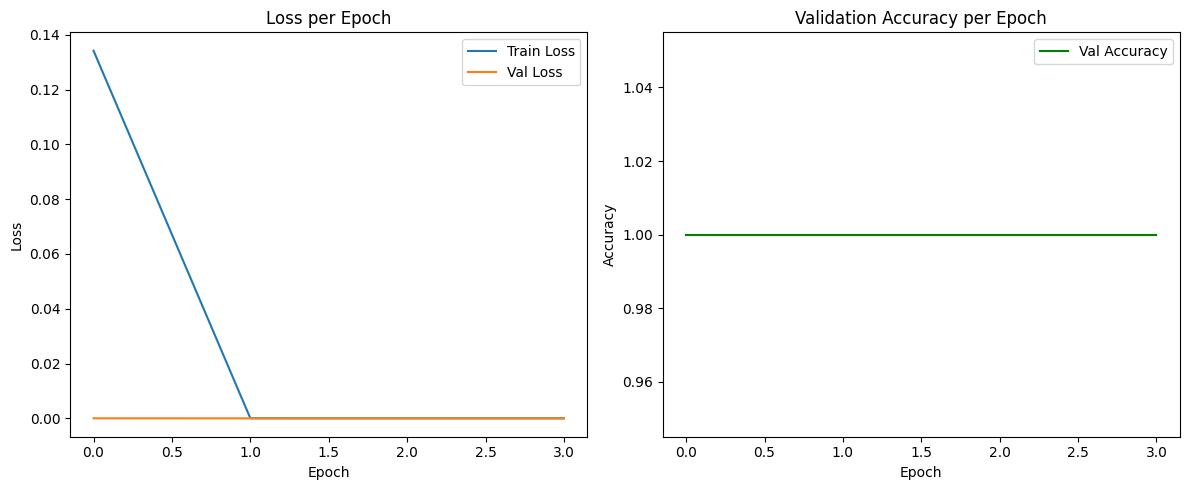

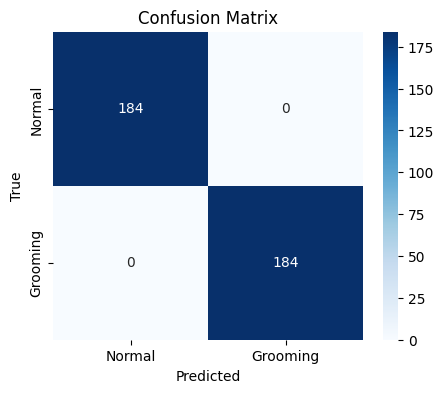

In [11]:
train_model(model, train_dataset, val_dataset, tokenizer)